<a href="https://colab.research.google.com/github/NikitaIvagin/ml-portfolio/blob/main/reinforcement_learning/rl_comparison_chess/%D0%A0%D0%B5%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F_%D0%B8_%D1%81%D1%80%D0%B0%D0%B2%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%BE%D0%B2_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D1%8F_%D1%81_%D0%BF%D0%BE%D0%B4%D0%BA%D1%80%D0%B5%D0%BF%D0%BB%D0%B5%D0%BD%D0%B8%D0%B5%D0%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. ВВОДНАЯ ЧАСТЬ

## Реализация и сравнение алгоритмов обучения с подкреплением (Reinforcement Learning) для игры в шахматы


## Автор - Ивагин Никита Михайлович

## Краткая аннотация
В данном ноутбуке производится реализация и сравнительный анализ трех алгоритмов обучения с подкреплением: Behavioral Cloning (BC), Deep Q-Network (DQN) и REINFORCE, примененных к задаче игры в шахматы. Используется датасет Chess-Alpha-700K и среда gym-chess для обучения и оценки агентов. Будет продемонстрирована подготовка данных, определение архитектур моделей, процесс обучения и оценка производительности каждого алгоритма.

# 2. УСТАНОВКА И ИМПОРТ БИБЛИОТЕК

In [ ]:
!pip install datasets torch accelerate transformers gym-chess cairosvg pillow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.6/134.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 43.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed 2026.1.1 requires cloudpickle>=3.0.0, but you have cloudpickle 1.6.0 which is incompatible.
dask 2026.1.1 requires cloudpickle>=3.0.0, but you have cloudpickle 1.6.0 which is incompatible.
bigframes 2.39.0 requires cloudpickle>=2.0.0, but you have cloudpickle 1.6.0 which is incompatible.


In [ ]:
import os
import gc
import io
import gym
import math
import chess
import torch
import random
import cairosvg
import requests
import datasets
import chess.svg
import gym_chess
import numpy as np
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from huggingface_hub import hf_hub_download
from torch.distributions import Categorical
from torch.utils.data import Dataset, DataLoader

# 3. ТЕОРЕТИЧЕСКАЯ ЧАСТЬ

### 3.1 Краткое описание проблемы

Игра в шахматы является классической задачей для обучения с подкреплением из-за ее сложности, большой размерности пространства состояний и действий, а также отложенной награды. Цель состоит в том, чтобы обучить искусственного агента принимать оптимальные решения (ходы) в шахматной игре, максимизируя свои шансы на победу. Это подразумевает не только понимание текущего состояния доски, но и прогнозирование будущих ходов противника и их последствий. Основные вызовы включают:

*   **Большое пространство состояний:** Количество возможных конфигураций шахматной доски велико.
*   **Большое пространство действий:** В любой момент времени возможно множество легальных ходов.
*   **Отложенная награда:** Окончательная награда (победа, поражение, ничья) получается только в конце игры, что затрудняет привязку конкретных ходов к конечному результату.
*   **Неполная информация:** Хотя состояние доски полностью наблюдаемо, истинная "ценность" позиции часто скрыта и требует глубокого анализа.

### 3.2 Основные концепции

Для решения проблемы шахмат с использованием обучения с подкреплением применяются следующие ключевые концепции:

*   **Среда (Environment):** В данном случае средой является шахматная игра, представленная библиотекой `gym-chess`. Она определяет правила игры, начальные условия и механизмы для выполнения ходов.
*   **Агент (Agent):** Программа, которая принимает решения (ходы) в среде. В данном ноутбуке мы рассматриваем три типа агентов: Behavioral Cloning (BC), Deep Q-Network (DQN) и REINFORCE.
*   **Состояние (State):** Текущее положение шахматной доски. В коде это представлено объектом `chess.Board`, который затем преобразуется в 15-слойный тензор `(15x8x8)` для нейронной сети, где каждый слой кодирует информацию о расположении фигур, чьем ходе, правах на рокировку и возможности взятия на проходе.
*   **Действие (Action):** Легальный ход, который агент может совершить в текущем состоянии. Действия представлены объектами `chess.Move` и маппируются в уникальные целочисленные ID (например, от 0 до 8191 в `MOVE_TO_ID`).
*   **Награда (Reward):** Числовое значение, получаемое агентом после совершения действия. В контексте шахмат награда может быть +1 за победу, -1 за поражение и 0 за ничью, или промежуточные награды за взятие фигур или достижение определенных позиций. В `gym-chess` обычно используется простая система наград.
*   **Политика (Policy):** Стратегия агента, которая определяет, какое действие совершить в данном состоянии. Может быть детерминированной (всегда выбирает один и тот же ход) или стохастической (выбирает ход на основе распределения вероятностей).
*   **Функция ценности (Value Function):** Предсказывает ожидаемую дисконтированную награду, которую агент получит, начиная с данного состояния и следуя определенной политике (Q-функция для DQN) или ожидаемую кумулятивную награду за выполнение определенного действия в определенном состоянии.

### 3.3 Математическое обоснование

Обучение с подкреплением часто формулируется как **Марковский процесс принятия решений (Markov Decision Process, MDP)**, который описывается кортежем $(\mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma)$:

*   $\mathcal{S}$: Множество состояний (все возможные конфигурации доски).
*   $\mathcal{A}$: Множество действий (все возможные легальные ходы).
*   $\mathcal{P}(s' | s, a)$: Вероятность перехода в состояние $s'$ при совершении действия $a$ в состоянии $s$. В детерминированных средах, таких как шахматы, эта вероятность равна 1 для следующего состояния и 0 для всех остальных.
*   $\mathcal{R}(s, a, s')$: Функция награды, определяющая награду за переход из состояния $s$ в $s'$ с помощью действия $a$.
*   $\gamma$: Фактор дисконтирования (discount factor), определяющий важность будущих наград относительно текущих.

**Deep Q-Network (DQN):** Основан на **уравнении Беллмана**, которое связывает Q-функцию (ожидаемую кумулятивную дисконтированную награду за выполнение действия $a$ в состоянии $s$ и дальнейшее следование оптимальной политике) с Q-функциями последующих состояний:

$$
Q(s, a) = R(s, a) + \gamma \max_{a'} Q(s', a')
$$

DQN использует нейронную сеть для аппроксимации Q-функции. Обучение происходит путем минимизации **функции потерь Хубера (Huber Loss)** (как правило) между предсказанными Q-значениями и целевыми Q-значениями, вычисленными с использованием целевой сети (Target Network) для стабильности.

**REINFORCE (Policy Gradient):** Относится к методам градиента политики. Цель состоит в том, чтобы непосредственно оптимизировать параметризованную политику $\pi_\theta(a|s)$ (вероятность выбора действия $a$ в состоянии $s$ с параметрами $\theta$), максимизируя ожидаемую кумулятивную награду. Градиент политики для REINFORCE дается выражением:

$$
\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t|s_t) G_t \right]
$$

где $G_t$ - это дисконтированная кумулятивная награда, полученная после момента времени $t$. Алгоритм обновляет параметры $\theta$ в направлении, которое увеличивает вероятность действий, приводящих к высоким наградам.

**Behavioral Cloning (BC):** Не является методом обучения с подкреплением в строгом смысле, а представляет собой метод обучения с учителем. Он учит политику, имитируя поведение эксперта. Нейронная сеть обучается на парах (состояние, действие эксперта), минимизируя **кросс-энтропийную потерю (Cross-Entropy Loss)**, которая измеряет различие между распределением вероятностей ходов, предсказываемых моделью, и "правильным" ходом, выбранным экспертом. По сути, это многоклассовая классификация, где состояния - это входные данные, а ходы эксперта - это целевые метки.

### 3.4 Схема архитектуры

Для всех трех алгоритмов (BC, DQN, REINFORCE) используется схожая нейросетевая архитектура, адаптированная для обработки шахматной доски как изображения или многослойной сетки. Это обеспечивает эффективное извлечение пространственных признаков:

1.  **Входной слой:** Принимает 15-слойный тензор `(15x8x8)`, представляющий текущее состояние шахматной доски. Каждый слой кодирует информацию о конкретном типе фигуры и ее цвете, а также дополнительную информацию о состоянии игры (чей ход, права на рокировку, взятие на проходе).

2.  **Сверточные слои (Convolutional Layers):**
    *   `conv1`: `nn.Conv2d(15, 64, kernel_size=3, padding=1)` – Первый сверточный слой с 15 входными каналами (соответствующими 15 слоям доски) и 64 выходными каналами. Использует ядро размером 3x3 с паддингом 1 для сохранения пространственного размера 8x8.
    *   `conv2`: `nn.Conv2d(64, 128, kernel_size=3, padding=1)` – Второй сверточный слой, увеличивающий количество каналов до 128.
    *   `conv3`: `nn.Conv2d(128, 256, kernel_size=3, padding=1)` – Третий сверточный слой, увеличивающий количество каналов до 256.
    *   Между сверточными слоями применяется функция активации `ReLU` (`F.relu`), чтобы добавить нелинейность.

3.  **Выпрямление (Flatten):** После сверточных слоев выходной тензор `(batch_size, 256, 8, 8)` выпрямляется в одномерный вектор `(batch_size, 256 * 8 * 8)` для подачи на вход полносвязным слоям.

4.  **Полносвязные слои (Fully Connected Layers):**
    *   `fc1`: `nn.Linear(256 * 8 * 8, 512)` – Первый полносвязный слой, преобразующий выпрямленные признаки в вектор размерности 512.
    *   `fc2`: `nn.Linear(512, num_actions)` – Выходной полносвязный слой. `num_actions` – это общее количество возможных действий (например, 8192, как определено в `ID_TO_MOVE`).

5.  **Выходной слой:**
    *   Для **Behavioral Cloning** и **REINFORCE** выход `fc2` интерпретируется как логиты для распределения вероятностей над всеми возможными действиями. Для REINFORCE затем применяется `softmax` (неявно через `Categorical` распределение) для получения вероятностей.
    *   Для **DQN** выход `fc2` представляет Q-значения для каждого возможного действия. Активация не применяется, так как Q-значения являются непрерывными.

# 4. ПОДГОТОВКА ДАННЫХ

### 4.1 Загрузка данных: Chess-Alpha-700K

In [ ]:
repo_id = "satana123/Chess-Alpha-700K"
file_in_repo = "multi_plan_dynamic_dataset.npz"

print(f"Скачиваем файл {file_in_repo} из репозитория {repo_id}...")

try:
    downloaded_file_path = hf_hub_download(repo_id=repo_id, filename=file_in_repo, repo_type="dataset")
    print(f"Файл успешно скачан в: {downloaded_file_path}")
except Exception as e:
    print(f"Ошибка при скачивании файла: {e}")
    exit()

# Загружаем данные из .npz файла с использованием memory-mapping и разрешая pickled данные
# Это позволит избежать загрузки всего файла в ОЗУ сразу.
data = np.load(downloaded_file_path, allow_pickle=True, mmap_mode='r')

print("Содержимое .npz файла:")
for key in data.keys():
    print(f"  Ключ: {key}, Форма: {data[key].shape}, Тип данных: {data[key].dtype}")

# Конвертируем загруженные numpy массивы в объект datasets.Dataset
# Передаем numpy массивы напрямую, без преобразования в списки Python, чтобы сэкономить память.
converted_data = {key: data[key] for key in data.keys()}

# Исправленная строка: используем datasets.Dataset.from_dict()
dataset_from_npz = datasets.Dataset.from_dict(converted_data)

# Удаляем оригинальный объект `data` из памяти, так как его содержимое теперь в `dataset_from_npz`
del data

print("\nДатасет из .npz файла успешно создан:")
print(dataset_from_npz)
print("Пример первой записи датасета:")
print(dataset_from_npz[0])

# Теперь `dataset_from_npz` содержит наши данные и готов к дальнейшей обработке.

Скачиваем файл multi_plan_dynamic_dataset.npz из репозитория satana123/Chess-Alpha-700K...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


multi_plan_dynamic_dataset.npz:   0%|          | 0.00/34.0M [00:00<?, ?B/s]

Файл успешно скачан в: /root/.cache/huggingface/hub/datasets--satana123--Chess-Alpha-700K/snapshots/e5c754c6075315a53040678690cec3c4d3dc231d/multi_plan_dynamic_dataset.npz
Содержимое .npz файла:
  Ключ: states, Форма: (706414, 15, 8, 8), Тип данных: int8
  Ключ: evals, Форма: (706414,), Тип данных: float32
  Ключ: deltas, Форма: (706414,), Тип данных: float32
  Ключ: plans, Форма: (706414, 3, 8), Тип данных: int32

Датасет из .npz файла успешно создан:
Dataset({
    features: ['states', 'evals', 'deltas', 'plans'],
    num_rows: 706414
})
Пример первой записи датасета:
{'states': [[[0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 1, 1, 0, 1, 1, 1], [0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]], [[0, 1, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 

## 4.2 Подготовка среды: Chess Environment

In [ ]:
# Создание среды Chess-v0
# Используем render_mode='rgb_array' для визуализации, если потребуется
env = gym.make('Chess-v0')

print(f"Среда Chess-v0 успешно инициализирована: {env}")

print("Пространство наблюдений:")
print("Наблюдение является объектом python-chess Board.")

print("\nПространство действий:")
print("Действия применяются к объекту python-chess Board (например, chess.Move, SAN или UCI).")

# Пример сброса среды и получения начального наблюдения
# env.reset() возвращает только объект chess.Board
observation = env.reset()
print("\nПример начального наблюдения (начальная позиция доски):")
print(observation) # Печать объекта доски (FEN-строка или строковое представление)

Среда Chess-v0 успешно инициализирована: <Chess<Chess-v0>>
Пространство наблюдений:
Наблюдение является объектом python-chess Board.

Пространство действий:
Действия применяются к объекту python-chess Board (например, chess.Move, SAN или UCI).

Пример начального наблюдения (начальная позиция доски):
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R


## 4.3 Визуализация начального состояния доски

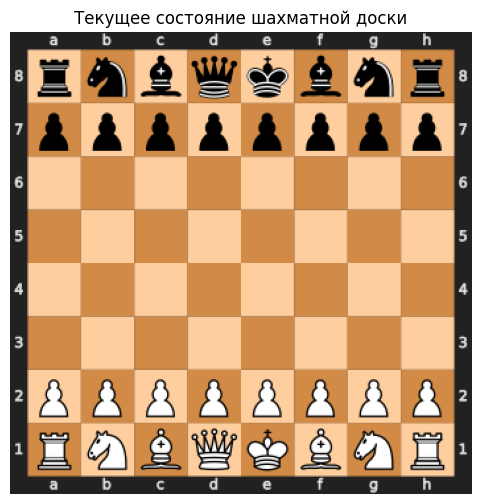

In [ ]:
# Получаем текущее состояние доски из среды
current_board_state = env.reset()

# Конвертируем объект chess.Board в SVG строку
board_svg = chess.svg.board(board=current_board_state, size=350)

# Конвертируем SVG в PNG
png_bytes = cairosvg.svg2png(bytestring=board_svg)

# Открываем PNG с помощью PIL (Pillow)
img = Image.open(io.BytesIO(png_bytes))

# Отображаем изображение
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title('Текущее состояние шахматной доски')
plt.axis('off')
plt.show()

## 4.4 Разделение на train/val/test

В данном проекте явное разделение на train/val/test не используется в традиционном смысле. Для Behavioral Cloning весь доступный датасет используется для обучения модели имитации эксперта. Для алгоритмов DQN и REINFORCE обучение происходит путем взаимодействия агента со средой, где агент генерирует собственный опыт.

# 5. РЕАЛИЗАЦИЯ МОДЕЛЕЙ

## 5.1 Behavioral Cloning (Baseline)

### 5.1.1 Подготовка данных для Behavioral Cloning

In [ ]:
# Преобразуем формат данных из dataset_from_npz для Behavioral Cloning

# Для адаптации под ограничения колаба
BOARD = 250000 # Оригинальный датасет имеет 700К записей.

class ChessBCDataset(Dataset):
    def __init__(self, states, plans):
        self.states = states
        self.actions = []
        self.filtered_states = []

        for i in range(len(plans)):
            # plans[i] является списком массивов, например: [[231, ...], [2673, ...], ...]
            # Мы ищем первый массив, у которого первый элемент (ID хода) не равен 0
            valid_action_arrays = [action_arr for action_arr in plans[i] if action_arr[0] != 0]
            if valid_action_arrays:
                self.actions.append(valid_action_arrays[0][0])
                self.filtered_states.append(states[i])

        self.states = torch.tensor(self.filtered_states, dtype=torch.float32)
        self.actions = torch.tensor(self.actions, dtype=torch.long)

    def __len__(self):
        return len(self.actions)

    def __getitem__(self, idx):
        return self.states[idx], self.actions[idx]

# Инициализация датасета для Behavioral Cloning
bc_dataset = ChessBCDataset(dataset_from_npz['states'][:BOARD], dataset_from_npz['plans'][:BOARD])

print(f"Размер датасета BC: {len(bc_dataset)}")
print(f"Пример состояния: {bc_dataset[0][0].shape}")
print(f"Пример действия: {bc_dataset[0][1]}")

# Создаем DataLoader
batch_size = 128
bc_dataloader = DataLoader(bc_dataset, batch_size=batch_size, shuffle=True)

print(f"Количество батчей в DataLoader: {len(bc_dataloader)}")

Размер датасета BC: 250000
Пример состояния: torch.Size([15, 8, 8])
Пример действия: 231
Количество батчей в DataLoader: 1954


### 5.1.2 Определение модели Behavioral Cloning

In [ ]:
# Глобальные словари для маппинга Move <-> ID
MOVE_TO_ID = {}
ID_TO_MOVE = {}

def initialize_move_mapping():
    """Инициализирует глобальные словари MOVE_TO_ID и ID_TO_MOVE для всех возможных ходов."""
    global MOVE_TO_ID, ID_TO_MOVE
    MOVE_TO_ID = {}
    ID_TO_MOVE = {}
    count = 0
    # Итерируем по всем возможным комбинациям начальных и конечных полей
    for from_square in chess.SQUARES:
        for to_square in chess.SQUARES:
            # Непромоционные ходы
            move = chess.Move(from_square, to_square)
            MOVE_TO_ID[move] = count
            ID_TO_MOVE[count] = move
            count += 1

            # Ходы с промоцией (для ферзя, ладьи, слона, коня)
            if chess.square_rank(to_square) in [0, 7]: # Промоция возможна только на 1-й или 8-й горизонтали
                for promotion_piece in [chess.QUEEN, chess.ROOK, chess.BISHOP, chess.KNIGHT]:
                    # Проверяем, что это не пешка, иначе это будет некорректная промоция
                    # (промоция пешки, но мы создали Move без указания piece_type)
                    # В данном случае, мы создаем Move с promotion, который потом может быть отфильтрован по легальности.
                    move_promo = chess.Move(from_square, to_square, promotion=promotion_piece)
                    if move_promo not in MOVE_TO_ID: # Избегаем дубликатов для одного и того же (from, to)
                        MOVE_TO_ID[move_promo] = count
                        ID_TO_MOVE[count] = move_promo
                        count += 1

    print(f"Инициализировано {count} уникальных ID ходов.")

initialize_move_mapping()

Инициализировано 8192 уникальных ID ходов.


In [ ]:
class BehavioralCloningModel(nn.Module):
    def __init__(self, input_channels=15, output_actions=len(ID_TO_MOVE)): # Используем len(ID_TO_MOVE) для полного пространства действий
        super(BehavioralCloningModel, self).__init__()
        # Вход: (batch_size, 15, 8, 8) - 15 слоев, 8x8 доска
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)

        # Для определения размера входного слоя для FC, нужно рассчитать выход сверточных слоев
        # 8x8 -> 8x8 -> 8x8
        # 256 * 8 * 8 = 16384
        self.fc1 = nn.Linear(256 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, output_actions)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))

        x = x.view(x.size(0), -1) # Flatten

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Используем полный размер пространства действий, чтобы соответствовать среде и другим моделям
bc_model = BehavioralCloningModel(output_actions=len(ID_TO_MOVE))
print("Модель Behavioral Cloning успешно определена:")
print(bc_model)

Модель Behavioral Cloning успешно определена:
BehavioralCloningModel(
  (conv1): Conv2d(15, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=16384, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=8192, bias=True)
)


### 5.1.3 Оптимизация обучения модели

In [ ]:
# Определение функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss() # Подходит для многоклассовой классификации (выбор хода)
optimizer = optim.Adam(bc_model.parameters(), lr=0.001)

# Перенос модели на GPU, если доступно
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bc_model.to(device)

print(f"Модель будет обучаться на: {device}")

Модель будет обучаться на: cuda


### 5.1.4 Обучение

Эпоха 1/30 BC:   0%|          | 0/1954 [00:00<?, ?it/s]

Эпоха [1/30], Потери: 5.4663


Эпоха 2/30 BC:   0%|          | 0/1954 [00:00<?, ?it/s]

Эпоха [2/30], Потери: 3.7959


Эпоха 3/30 BC:   0%|          | 0/1954 [00:00<?, ?it/s]

...

Эпоха [28/30], Потери: 0.3268


Эпоха 29/30 BC:   0%|          | 0/1954 [00:00<?, ?it/s]

Эпоха [29/30], Потери: 0.3170


Эпоха 30/30 BC:   0%|          | 0/1954 [00:00<?, ?it/s]

Эпоха [30/30], Потери: 0.3202


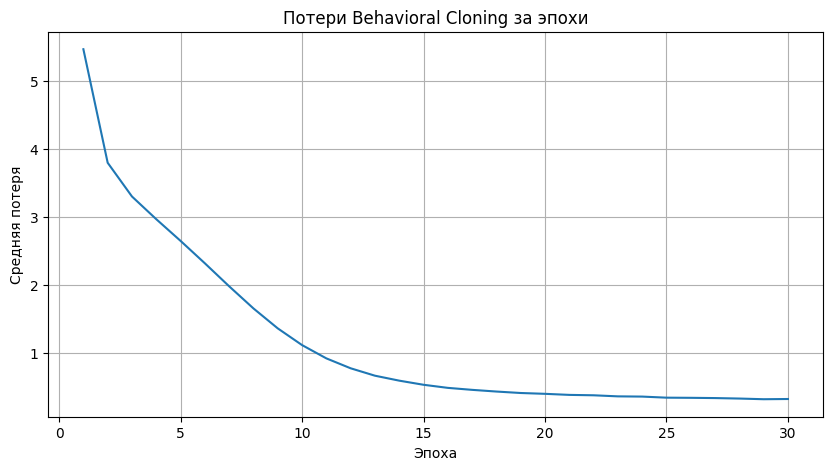

In [ ]:
# Гиперпараметр обучения
NUM_EPOCHS = 30

epoch_losses = []
for epoch in range(NUM_EPOCHS):
    bc_model.train() # Устанавливаем модель в режим обучения
    running_loss = 0.0
    for i, (states, actions) in enumerate(tqdm(bc_dataloader, desc=f"Эпоха {epoch+1}/{NUM_EPOCHS} BC", leave=False)):
        states, actions = states.to(device), actions.to(device);

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        outputs = bc_model(states)
        loss = criterion(outputs, actions)

        # Обратный проход и оптимизация
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(bc_dataloader)
    epoch_losses.append(avg_loss)
    print(f"Эпоха [{epoch + 1}/{NUM_EPOCHS}], Потери: {avg_loss:.4f}")

# Визуализация потерь Behavioral Cloning
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), epoch_losses)
plt.title('Потери Behavioral Cloning за эпохи')
plt.xlabel('Эпоха')
plt.ylabel('Средняя потеря')
plt.grid(True)
plt.show()

### 5.1.5 Очистка памяти после обучения

In [ ]:
# Удаление объектов, связанных с Behavioral Cloning (кроме самой модели)
if 'bc_dataset' in locals():
    del bc_dataset
if 'bc_dataloader' in locals():
    del bc_dataloader

# Удаление исходного датасета, т.к. он больше не нужен для других этапов
if 'dataset_from_npz' in locals():
    del dataset_from_npz
if 'converted_data' in locals():
    del converted_data

# Принудительный запуск сборщика мусора
gc.collect()

34003302

## 5.2 Deep Q-Network (DQN)


### 5.2.1 Определение модели DQN

In [ ]:
class DQNAgent(nn.Module):
    def __init__(self, input_channels=15, num_actions=4096): # num_actions - количество возможных уникальных ходов
        super(DQNAgent, self).__init__()
        # Вход: (batch_size, 15, 8, 8) - 15 слоев, 8x8 доска
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)

        # Размер входного слоя для FC
        self.fc1 = nn.Linear(256 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_actions) # Выход: Q-значение для каждого действия

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))

        x = x.view(x.size(0), -1) # Flatten

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Инициализация основной сети и целевой сети DQN
# Используем тот же max_action_id, что и для BC, чтобы покрыть все возможные действия из датасета
dqn_policy_net = DQNAgent(num_actions=len(ID_TO_MOVE)).to(device)
dqn_target_net = DQNAgent(num_actions=len(ID_TO_MOVE)).to(device)
dqn_target_net.load_state_dict(dqn_policy_net.state_dict())
dqn_target_net.eval() # Целевая сеть находится в режиме оценки (не обучается)

print("Основная DQN сеть успешно определена:")
print(dqn_policy_net)
print("\nЦелевая DQN сеть успешно определена:")
print(dqn_target_net)

Основная DQN сеть успешно определена:
DQNAgent(
  (conv1): Conv2d(15, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=16384, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=8192, bias=True)
)

Целевая DQN сеть успешно определена:
DQNAgent(
  (conv1): Conv2d(15, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=16384, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=8192, bias=True)
)


### 5.2.2 Буфер опыта (Experience Replay Buffer)

Для того чтобы DQN агент мог принимать решения, основанные на предсказаниях своей сети, нам необходимо создать систему для преобразования шахматных ходов (`chess.Move`) в уникальные целочисленные ID (которые предсказывает нейронная сеть) и обратно. Также потребуется механизм для маскирования нелегальных ходов в выходном слое сети.

Следующие функции помогут в этом:

In [ ]:
# Для DQN мы будем использовать Huber Loss, который менее чувствителен к выбросам, чем MSE.
loss_fn_dqn = nn.SmoothL1Loss()

Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Сохраняет переход в буфер"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        """Случайно выбирает batch_size переходов из буфера"""
        return random.sample(self.memory, batch_size)

    def __len__(self):
        """Возвращает текущий размер буфера"""
        return len(self.memory)

# Инициализация буфера опыта
replay_buffer = ReplayBuffer(capacity=10000) # Можно настроить размер буфера
print(f"Буфер опыта инициализирован с емкостью: {replay_buffer.capacity if hasattr(replay_buffer, 'capacity') else len(replay_buffer.memory)}")

Буфер опыта инициализирован с емкостью: 0


### 5.2.3 Функции для DQN

In [ ]:
def board_to_tensor(board: chess.Board) -> torch.Tensor:
    """Преобразует объект chess.Board в 15-слойный тензор (15x8x8)."""
    # Инициализируем 15 пустых слоев
    # 6 слоев для каждого цвета (пешка, конь, слон, ладья, ферзь, король)
    # 1 слой для текущего игрока
    # 1 слой для полных ходов (не реализовано в dataset, но можно добавить)
    # 1 слой для права рокировки (king-side white, queen-side white, king-side black, queen-side black)
    # 1 слой для взятия на проходе
    # 1 слой для счетчика полуходов

    board_tensor = torch.zeros(15, 8, 8, dtype=torch.float32)

    # Слой 0-5: Белые фигуры (P, N, B, R, Q, K)
    # Слой 6-11: Черные фигуры (p, n, b, r, q, k)
    piece_to_layer = {
        chess.PAWN: 0, chess.KNIGHT: 1, chess.BISHOP: 2,
        chess.ROOK: 3, chess.QUEEN: 4, chess.KING: 5
    }

    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece:
            row, col = chess.square_rank(square), chess.square_file(square)
            layer_offset = 0 if piece.color == chess.WHITE else 6
            board_tensor[piece_to_layer[piece.piece_type] + layer_offset, row, col] = 1

    # Слой 12: Чей ход (1 для белых, 0 для черных - или -1 для черных в некоторых схемах)
    if board.turn == chess.WHITE:
        board_tensor[12, :, :] = 1
    else:
        board_tensor[12, :, :] = 0 # Или -1, если сеть ожидает симметричное представление

    # Слой 13: Права рокировки
    if board.has_kingside_castling_rights(chess.WHITE): board_tensor[13, 0, 7] = 1 # h1
    if board.has_queenside_castling_rights(chess.WHITE): board_tensor[13, 0, 0] = 1 # a1
    if board.has_kingside_castling_rights(chess.BLACK): board_tensor[13, 7, 7] = 1 # h8
    if board.has_queenside_castling_rights(chess.BLACK): board_tensor[13, 7, 0] = 1 # a8

    # Слой 14: Взятие на проходе
    if board.ep_square:
        row, col = chess.square_rank(board.ep_square), chess.square_file(board.ep_square)
        board_tensor[14, row, col] = 1

    return board_tensor.unsqueeze(0) # Добавляем размерность батча

In [ ]:
def select_action(state, policy_net, current_board, epsilon):
    """Выбирает действие с использованием эпсилон-жадной стратегии, учитывая легальные ходы."""
    global MOVE_TO_ID, ID_TO_MOVE

    # Получаем список легальных ходов для текущей доски
    legal_moves = list(current_board.legal_moves)

    # Если легальных ходов нет, это конец игры
    if not legal_moves:
        return None, None # Возвращаем None для action_id_tensor и actual_move

    # Создаем маску для легальных ходов
    # Инициализируем маску, где все ходы нелегальны (False)
    legal_moves_mask = torch.zeros(len(ID_TO_MOVE), dtype=torch.bool, device=state.device)

    # Устанавливаем True для ID легальных ходов
    for move in legal_moves:
        if move in MOVE_TO_ID:
            move_id = MOVE_TO_ID[move]
            if move_id < len(ID_TO_MOVE): # Проверка на границы, если MOVE_TO_ID больше чем ID_TO_MOVE
                legal_moves_mask[move_id] = True

    sample = random.random()
    if sample > epsilon: # Эксплуатация (выбираем лучший Q-value из легальных)
        with torch.no_grad():
            q_values = policy_net(state)

            # Маскируем Q-значения нелегальных ходов, устанавливая их в очень маленькое число
            # (или -inf), чтобы они не были выбраны argmax.
            # Используем clone(), чтобы избежать модификации оригинального тензора.
            masked_q_values = q_values.clone()
            masked_q_values[0, ~legal_moves_mask] = -float('inf')

            # Если все легальные ходы были замаскированы (что не должно произойти, если legal_moves не пуст)
            if (masked_q_values[0] == -float('inf')).all():
                # Fallback: Выбираем случайный легальный ход
                actual_move = random.choice(legal_moves)
                action_id = MOVE_TO_ID.get(actual_move, -1) # Получаем ID, если возможно
                if action_id == -1: # Если move не в маппинге, нужно выбрать случайный ID из допустимых
                     action_id = random.choice(torch.nonzero(legal_moves_mask, as_tuple=True)[0]).item()
                action_id_tensor = torch.tensor([[action_id]], device=state.device, dtype=torch.long)
            else:
                # Выбираем действие с максимальным Q-значением из легальных
                action_id_tensor = masked_q_values.max(1)[1].view(1, 1)
                action_id = action_id_tensor.item()
                actual_move = ID_TO_MOVE.get(action_id) # Получаем объект move

                # Дополнительная проверка на легальность: если каким-то образом выбранный ID не соответствует
                # легальному ходу, выбираем случайный легальный. Это страховка.
                if actual_move not in legal_moves:
                    actual_move = random.choice(legal_moves)
                    action_id = MOVE_TO_ID.get(actual_move, -1)
                    if action_id == -1:
                        action_id = random.choice(torch.nonzero(legal_moves_mask, as_tuple=True)[0]).item()
                    action_id_tensor = torch.tensor([[action_id]], device=state.device, dtype=torch.long)

    else: # Исследование (выбираем случайный легальный ход)
        actual_move = random.choice(legal_moves)
        action_id = MOVE_TO_ID.get(actual_move, -1) # Получаем ID, если возможно

        # Если move не в маппинге (что не должно произойти, если MOVE_TO_ID полностью инициализирован)
        if action_id == -1:
            # Fallback: выбираем случайный ID из легальных позиций в маске
            action_id = random.choice(torch.nonzero(legal_moves_mask, as_tuple=True)[0]).item()
            actual_move = ID_TO_MOVE.get(action_id) # Повторно получаем move
        action_id_tensor = torch.tensor([[action_id]], device=state.device, dtype=torch.long)

    return action_id_tensor, actual_move

### 5.2.4 Обучение

Обучение DQN:   0%|          | 0/500 [00:00<?, ?it/s]

Эпизод: 25/500, Средняя награда за последние 25 эпизодов: 10.04
Эпизод: 50/500, Средняя награда за последние 25 эпизодов: 12.55
Эпизод: 75/500, Средняя награда за последние 25 эпизодов: 9.12
Эпизод: 100/500, Средняя награда за последние 25 эпизодов: 9.33
Эпизод: 125/500, Средняя награда за последние 25 эпизодов: 8.84
Эпизод: 150/500, Средняя награда за последние 25 эпизодов: 8.29
Эпизод: 175/500, Средняя награда за последние 25 эпизодов: 7.75
Эпизод: 200/500, Средняя награда за последние 25 эпизодов: 8.21
Эпизод: 225/500, Средняя награда за последние 25 эпизодов: 8.10
Эпизод: 250/500, Средняя награда за последние 25 эпизодов: 8.19
Эпизод: 275/500, Средняя награда за последние 25 эпизодов: 8.72
Эпизод: 300/500, Средняя награда за последние 25 эпизодов: 8.44
Эпизод: 325/500, Средняя награда за последние 25 эпизодов: 7.55
Эпизод: 350/500, Средняя награда за последние 25 эпизодов: 7.88
Эпизод: 375/500, Средняя награда за последние 25 эпизодов: 8.95
Эпизод: 400/500, Средняя награда за после

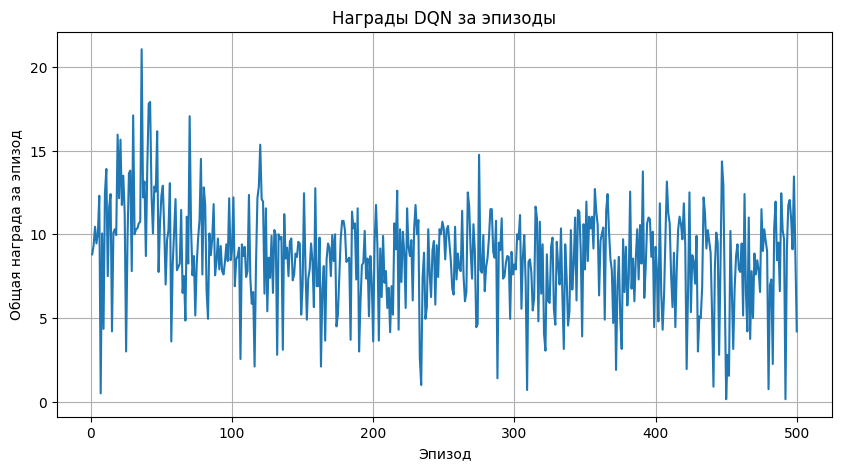

In [ ]:
BATCH_SIZE = 32 # Размер батча для обучения DQN
GAMMA = 0.99   # Фактор дисконтирования для DQN
EPS_START = 0.9 # Начальное значение эпсилон для эпсилон-жадной стратегии DQN
EPS_END = 0.05  # Конечное значение эпсилон DQN
EPS_DECAY = 5000 # Скорость затухания эпсилон DQN.
TARGET_UPDATE = 10 # Как часто обновлять целевую сеть DQN (в эпизодах)
DQN_NUM_EPISODES = 500 # Количество эпизодов для обучения DQN.
MAX_STEPS_PER_EPISODE = 10000 # Максимальное количество шагов в одном эпизоде.

# Дополнительные награды для формирования (Reward Shaping)
CHECK_REWARD = 0.1
CAPTURE_REWARD = 0.2
CENTER_CONTROL_REWARD = 0.05
central_squares = {chess.D4, chess.D5, chess.E4, chess.E5}

# Инициализация основной сети и целевой сети DQN с корректным num_actions
# Пересоздаем, чтобы убедиться, что количество выходных действий соответствует нашему маппингу
dqn_policy_net = DQNAgent(num_actions=len(ID_TO_MOVE)).to(device)
dqn_target_net = DQNAgent(num_actions=len(ID_TO_MOVE)).to(device)
dqn_target_net.load_state_dict(dqn_policy_net.state_dict())
dqn_target_net.eval()

optimizer_dqn = optim.Adam(dqn_policy_net.parameters(), lr=0.0001)

steps_done = 0
episode_rewards = []

for i_step in tqdm(range(DQN_NUM_EPISODES), desc="Обучение DQN", leave=True):
    current_board = env.reset()
    state = board_to_tensor(current_board).to(device)

    total_episode_reward = 0
    done = False
    episode_step_count = 0
    while not done and episode_step_count < MAX_STEPS_PER_EPISODE:
        epsilon = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)

        # Используем обновленную функцию select_action
        action_id_tensor, actual_move = select_action(state, dqn_policy_net, current_board, epsilon)

        # Если select_action вернул None (нет легальных ходов), завершаем эпизод
        if actual_move is None:
            break

        # Сохраняем состояние доски до хода для проверки взятий
        board_before_step = current_board.copy()

        # Шаг в среде
        next_board_obs, reward_env, done, _ = env.step(actual_move)

        shaped_reward = reward_env # Начинаем с базовой награды среды

        # Добавляем награду за шах
        if next_board_obs.is_check():
            shaped_reward += CHECK_REWARD

        # Добавляем награду за взятие фигуры
        if board_before_step.is_capture(actual_move):
            shaped_reward += CAPTURE_REWARD

        # Добавляем награду за контроль центра
        if actual_move.to_square in central_squares:
            shaped_reward += CENTER_CONTROL_REWARD

        reward = torch.tensor([shaped_reward], device=device, dtype=torch.float32)
        total_episode_reward += reward.item()

        next_state = board_to_tensor(next_board_obs).to(device)

        replay_buffer.push(state, action_id_tensor, reward, next_state, torch.tensor([done], device=device, dtype=torch.bool))

        state = next_state
        current_board = next_board_obs
        steps_done += 1
        episode_step_count += 1

        if len(replay_buffer) > BATCH_SIZE:
            transitions = replay_buffer.sample(BATCH_SIZE)
            batch = Transition(*zip(*transitions))

            non_final_mask = torch.cat([~s.cpu() for s in batch.done]).to(device)
            non_final_next_states = torch.cat(batch.next_state)[non_final_mask].to(device)

            state_batch = torch.cat(batch.state).to(device)
            action_batch = torch.cat(batch.action).to(device)
            reward_batch = torch.cat(batch.reward).to(device)

            state_action_values = dqn_policy_net(state_batch).gather(1, action_batch)

            next_state_values = torch.zeros(BATCH_SIZE, device=device)
            if non_final_next_states.numel() > 0:
                 next_state_values[non_final_mask] = dqn_target_net(non_final_next_states).max(1)[0].detach()

            expected_state_action_values = (next_state_values * GAMMA) + reward_batch

            loss = loss_fn_dqn(state_action_values, expected_state_action_values.unsqueeze(1))

            optimizer_dqn.zero_grad()
            loss.backward()
            for param in dqn_policy_net.parameters():
                param.grad.data.clamp_(-1, 1)
            optimizer_dqn.step()

    episode_rewards.append(total_episode_reward)

    if i_step % TARGET_UPDATE == 0:
        dqn_target_net.load_state_dict(dqn_policy_net.state_dict())

    if (i_step + 1) % 25 == 0:
        print(f"Эпизод: {i_step + 1}/{DQN_NUM_EPISODES}, Средняя награда за последние 25 эпизодов: {sum(episode_rewards[-25:]) / 25:.2f}") # Fixed division by 25

# Визуализация наград DQN
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(episode_rewards) + 1), episode_rewards)
plt.title('Награды DQN за эпизоды')
plt.xlabel('Эпизод')
plt.ylabel('Общая награда за эпизод')
plt.grid(True)
plt.show()

### 5.2.5 Очистка памяти после обучения DQN

In [ ]:
# Удаление буфера опыта DQN
if 'replay_buffer' in locals():
    del replay_buffer

# Принудительный запуск сборщика мусора
gc.collect()

3043

## 5.3 Policy Gradient (REINFORCE)

### 5.3.1 Определение модели REINFORCE

In [ ]:
class PolicyNet(nn.Module):
    def __init__(self, input_channels=15, num_actions=len(ID_TO_MOVE)):
        super(PolicyNet, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(256 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_actions)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        # Выходной слой без активации, так как Categorical будет использовать логиты
        return self.fc2(x)

# Инициализация Policy Network для REINFORCE
pg_policy_net = PolicyNet(num_actions=len(ID_TO_MOVE)).to(device)
pg_optimizer = optim.Adam(pg_policy_net.parameters(), lr=0.001)

print("REINFORCE Policy Network успешно определена:")
print(pg_policy_net)

REINFORCE Policy Network успешно определена:
PolicyNet(
  (conv1): Conv2d(15, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=16384, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=8192, bias=True)
)


### 5.3.2 Обучение модели REINFORCE

Обучение REINFORCE:   0%|          | 0/1000 [00:00<?, ?it/s]

Эпизод: 50/1000, Средняя награда за последние 50 эпизодов: 3.41
Эпизод: 100/1000, Средняя награда за последние 50 эпизодов: 1.74
Эпизод: 150/1000, Средняя награда за последние 50 эпизодов: 2.10
Эпизод: 200/1000, Средняя награда за последние 50 эпизодов: 2.85
Эпизод: 250/1000, Средняя награда за последние 50 эпизодов: 2.85
Эпизод: 300/1000, Средняя награда за последние 50 эпизодов: 2.85
Эпизод: 350/1000, Средняя награда за последние 50 эпизодов: 2.85
Эпизод: 400/1000, Средняя награда за последние 50 эпизодов: 2.85
Эпизод: 450/1000, Средняя награда за последние 50 эпизодов: 2.85
Эпизод: 500/1000, Средняя награда за последние 50 эпизодов: 2.85
Эпизод: 550/1000, Средняя награда за последние 50 эпизодов: 2.85
Эпизод: 600/1000, Средняя награда за последние 50 эпизодов: 2.85
Эпизод: 650/1000, Средняя награда за последние 50 эпизодов: 2.85
Эпизод: 700/1000, Средняя награда за последние 50 эпизодов: 2.85
Эпизод: 750/1000, Средняя награда за последние 50 эпизодов: 2.85
Эпизод: 800/1000, Средняя 

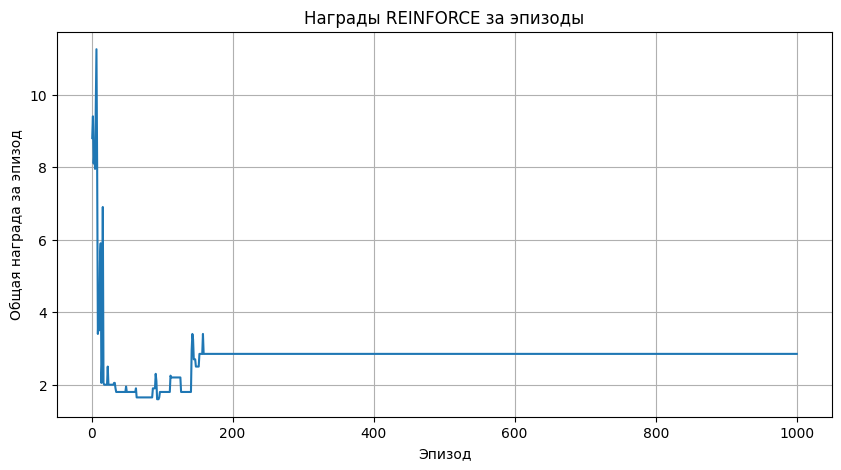

In [ ]:
# Гиперпараметры обучения
PG_LEARNING_RATE = 0.0001
PG_NUM_EPISODES = 1000 # Количество эпизодов для обучения REINFORCE.

# Дополнительные награды для формирования (Reward Shaping)
CHECK_REWARD = 0.1
CAPTURE_REWARD = 0.2
CENTER_CONTROL_REWARD = 0.05
central_squares = {chess.D4, chess.D5, chess.E4, chess.E5}

episode_rewards_pg = []

for i_episode in tqdm(range(PG_NUM_EPISODES), desc="Обучение REINFORCE", leave=True):
    saved_log_probs = []
    rewards = []
    current_board = env.reset()
    state = board_to_tensor(current_board).to(device)

    episode_total_reward = 0

    for t in range(MAX_STEPS_PER_EPISODE): # MAX_STEPS_PER_EPISODE уже определен как 200
        # Получаем логиты от политики
        logits = pg_policy_net(state)

        # Получаем легальные ходы
        legal_moves = list(current_board.legal_moves)
        if not legal_moves:
            break # Игра окончена (мат/пат)

        # Создаем маску для легальных ходов
        legal_moves_mask = torch.zeros(len(ID_TO_MOVE), dtype=torch.bool, device=device)
        for move in legal_moves:
            if move in MOVE_TO_ID:
                move_id = MOVE_TO_ID[move]
                if move_id < len(ID_TO_MOVE):
                    legal_moves_mask[move_id] = True

        # Маскируем логиты нелегальных ходов очень маленьким числом (-inf)
        masked_logits = logits.clone()
        masked_logits[0, ~legal_moves_mask] = -float('inf')

        # Создаем распределение Categorical из (замаскированных) логитов
        # Если все логиты стали -inf (что не должно произойти, т.к. legal_moves не пуст),
        # Categorical может вызвать ошибку. Добавим проверку.
        if (masked_logits[0] == -float('inf')).all():
            # Если все ходы нелегальны (что странно, т.к. legal_moves не пуст), выбираем случайный легальный ход
            actual_move = random.choice(legal_moves)
            action_id = MOVE_TO_ID.get(actual_move, -1)
            if action_id == -1:
                action_id = random.choice(torch.nonzero(legal_moves_mask, as_tuple=True)[0]).item()

            action = torch.tensor([action_id], device=device)
            log_prob = torch.tensor([0.0], device=device) # Не влияет на градиент
        else:
            m = Categorical(logits=masked_logits)
            action = m.sample() # Выбираем действие
            log_prob = m.log_prob(action) # Лог-вероятность выбранного действия

        saved_log_probs.append(log_prob)

        actual_move = ID_TO_MOVE.get(action.item()) # Конвертируем ID действия обратно в chess.Move

        # Сохраняем состояние доски до хода для проверки взятий
        board_before_step = current_board.copy()

        # Шаг в среде
        next_board_obs, reward_env, done, _ = env.step(actual_move)
        shaped_reward = reward_env # Начинаем с базовой награды среды

        # Добавляем награду за шах
        if next_board_obs.is_check():
            shaped_reward += CHECK_REWARD

        # Добавляем награду за взятие фигуры
        if board_before_step.is_capture(actual_move):
            shaped_reward += CAPTURE_REWARD

        # Добавляем награду за контроль центра
        if actual_move.to_square in central_squares:
            shaped_reward += CENTER_CONTROL_REWARD

        reward = shaped_reward # Используем сформированную награду
        rewards.append(reward)
        episode_total_reward += reward

        if done:
            break

        state = board_to_tensor(next_board_obs).to(device)
        current_board = next_board_obs

    episode_rewards_pg.append(episode_total_reward)

    # Расчет дисконтированных наград
    discounts = [GAMMA**i for i in range(len(rewards))]
    discounted_rewards = [r * d for r, d in zip(rewards, discounts)]

    # Нормализация дисконтированных наград
    # (часто помогает стабилизировать обучение Policy Gradient)
    discounted_rewards = torch.tensor(discounted_rewards, device=device)
    if len(discounted_rewards) > 1: # Избегаем деления на ноль для коротких эпизодов
        discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-9)

    # Расчет потерь (Policy Loss)
    policy_loss = []
    for log_prob, G in zip(saved_log_probs, discounted_rewards):
        policy_loss.append(-log_prob * G)

    pg_optimizer.zero_grad()
    torch.stack(policy_loss).sum().backward()
    pg_optimizer.step()

    if (i_episode + 1) % 50 == 0:
        print(f"Эпизод: {i_episode + 1}/{PG_NUM_EPISODES}, Средняя награда за последние 50 эпизодов: {sum(episode_rewards_pg[-50:]) / 50:.2f}")

# Визуализация наград REINFORCE
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(episode_rewards_pg) + 1), episode_rewards_pg)
plt.title('Награды REINFORCE за эпизоды')
plt.xlabel('Эпизод')
plt.ylabel('Общая награда за эпизод')
plt.grid(True)
plt.show()

### 5.3.3 Очистка памяти после обучения REINFORCE

In [ ]:
# Удаление временных объектов, связанных с REINFORCE обучением
if 'episode_rewards_pg' in locals():
    del episode_rewards_pg
if 'saved_log_probs' in locals():
    del saved_log_probs
if 'rewards' in locals():
    del rewards

# Принудительный запуск сборщика мусора
gc.collect()

3043

# 6. ОЦЕНКА

## 6.1 Расчет метрик и визуализация производительности


Начало оценки для BC (20 эпизодов)...


Оценка BC:   0%|          | 0/20 [00:00<?, ?it/s]

Средняя награда за 20 эпизодов для BC: 0.90 (ст. откл.: 0.00)

Начало оценки для DQN (20 эпизодов)...


Оценка DQN:   0%|          | 0/20 [00:00<?, ?it/s]

Средняя награда за 20 эпизодов для DQN: 0.75 (ст. откл.: 0.00)

Начало оценки для REINFORCE (20 эпизодов)...


Оценка REINFORCE:   0%|          | 0/20 [00:00<?, ?it/s]

Средняя награда за 20 эпизодов для REINFORCE: 2.85 (ст. откл.: 0.00)

Сравнение производительности:
BC Средняя награда: 0.90
DQN Средняя награда: 0.75
REINFORCE Средняя награда: 2.85

Сравнение процента побед:
BC Процент побед: 0.00%
DQN Процент побет: 0.00%
REINFORCE Процент побед: 0.00%


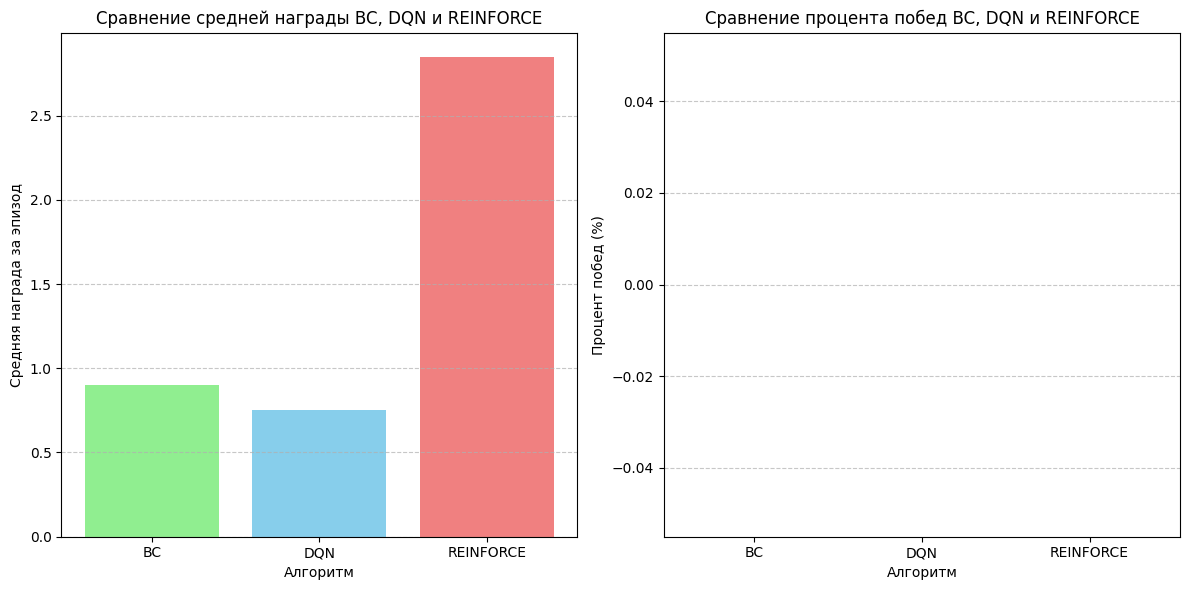

In [ ]:
def evaluate_agent(agent_net, agent_name, num_eval_episodes=10, is_dqn=False, is_reinforce=False, is_bc=False):
    """Оценивает производительность агента в среде gym-chess.

    Args:
        agent_net: Нейронная сеть агента (bc_model, policy_net для DQN, pg_policy_net для REINFORCE).
        agent_name: Название агента для вывода в консоль.
        num_eval_episodes: Количество эпизодов для оценки.
        is_dqn: Если True, используется логика выбора действия DQN (epsilon-greedy с epsilon=0).
        is_reinforce: Если True, используется логика выбора действия REINFORCE (сэмплирование из Categorical).
        is_bc: Если True, используется логика выбора действия Behavioral Cloning (argmax logits).

    Returns:
        Кортеж: (список наград, количество побед, количество поражений, количество ничьих)
    """
    print(f"\nНачало оценки для {agent_name} ({num_eval_episodes} эпизодов)...")
    agent_net.eval() # Переводим модель в режим оценки
    episode_rewards_eval = []
    win_count = 0
    loss_count = 0
    draw_count = 0

    for i_episode in tqdm(range(num_eval_episodes), desc=f"Оценка {agent_name}", leave=False):
        current_board = env.reset()
        state = board_to_tensor(current_board).to(device)
        episode_total_shaped_reward = 0
        final_raw_env_reward = 0.0
        episode_done = False

        for t in range(MAX_STEPS_PER_EPISODE):
            with torch.no_grad(): # Отключаем расчет градиентов для оценки
                action_id_tensor = None
                actual_move = None

                legal_moves = list(current_board.legal_moves)
                if not legal_moves:
                    episode_done = True
                    if current_board.is_checkmate():
                        final_raw_env_reward = 1.0
                    else:
                        final_raw_env_reward = 0.5
                    break

                logits = agent_net(state) # Получаем логиты от сети
                output_size = logits.shape[1] # Получаем фактический размер выходного слоя сети

                legal_moves_mask = torch.zeros(output_size, dtype=torch.bool, device=device)
                for move in legal_moves:
                    if move in MOVE_TO_ID:
                        move_id = MOVE_TO_ID[move]
                        if move_id < output_size: # Убеждаемся, что move_id находится в пределах размера вывода модели
                            legal_moves_mask[move_id] = True

                masked_logits = logits.clone()
                masked_logits[0, ~legal_moves_mask] = -float('inf')

                if (masked_logits[0] == -float('inf')).all():
                    # Fallback: Выбираем случайный легальный ход, если все замаскировано
                    actual_move = random.choice(legal_moves)
                    action_id = MOVE_TO_ID.get(actual_move, -1)
                    if action_id == -1:
                        action_id = random.choice(torch.nonzero(legal_moves_mask, as_tuple=True)[0]).item()
                    action_id_tensor = torch.tensor([action_id], device=device).view(1, 1)
                elif is_dqn:
                    # Для DQN выбираем действие жадно (epsilon=0)
                    action_id_tensor = masked_logits.max(1)[1].view(1, 1)
                elif is_reinforce:
                    # Для REINFORCE сэмплируем из распределения политики
                    try:
                        m = Categorical(logits=masked_logits)
                        action_id_tensor = m.sample().view(1, 1)
                    except ValueError:
                        actual_move = random.choice(legal_moves)
                        action_id = MOVE_TO_ID.get(actual_move, -1)
                        if action_id == -1:
                            action_id = random.choice(torch.nonzero(legal_moves_mask, as_tuple=True)[0]).item()
                        action_id_tensor = torch.tensor([action_id], device=device).view(1, 1)
                elif is_bc:
                    # Для BC выбираем действие с максимальной вероятностью (argmax)
                    action_id_tensor = masked_logits.max(1)[1].view(1, 1)
                else:
                    raise ValueError("Неизвестный тип агента для оценки")

                actual_move = ID_TO_MOVE.get(action_id_tensor.item())

                # Дополнительная проверка на легальность выбранного хода (на всякий случай)
                if actual_move not in legal_moves and legal_moves:
                    actual_move = random.choice(legal_moves)

            # Если ходов нет или выбранный ход почему-то None, завершаем эпизод
            if actual_move is None:
                episode_done = True
                break

            board_before_step = current_board.copy() # Сохраняем состояние доски до хода для проверки взятий
            next_board_obs, raw_env_reward, done_step, _ = env.step(actual_move)
            final_raw_env_reward = raw_env_reward
            episode_done = done_step

            shaped_reward = raw_env_reward # Начинаем с базовой награды среды

            # Добавляем награды за формирование (Reward Shaping) для всех агентов в режиме оценки
            # Это позволит видеть прогресс даже если игра не заканчивается победой/поражением
            if next_board_obs.is_check():
                shaped_reward += CHECK_REWARD

            if board_before_step.is_capture(actual_move):
                shaped_reward += CAPTURE_REWARD

            if actual_move.to_square in central_squares:
                shaped_reward += CENTER_CONTROL_REWARD

            episode_total_shaped_reward += shaped_reward

            if episode_done:
                break

            state = board_to_tensor(next_board_obs).to(device)
            current_board = next_board_obs

        episode_rewards_eval.append(episode_total_shaped_reward)

        # Определяем фактический результат игры на основе final_raw_env_reward или факта таймаута
        if episode_done: # Игра завершилась естественным образом (мат, пат, ничья)
            if final_raw_env_reward == 1.0: # Агент выиграл (поставил мат)
                win_count += 1
            elif final_raw_env_reward == -1.0: # Агент проиграл (получил мат)
                loss_count += 1
            elif final_raw_env_reward == 0.5: # Ничья (пат, 50 ходов, повторение, мало материала)
                draw_count += 1
            else: # Если raw_env_reward 0.0, но done=True, это должна быть ничья (например, по малому материалу, но среда может вернуть 0 вместо 0.5)
                draw_count += 1
        else: # Игра завершилась по MAX_STEPS_PER_EPISODE (таймаут), считаем ничьей
            draw_count += 1

    mean_reward = np.mean(episode_rewards_eval)
    std_reward = np.std(episode_rewards_eval)
    print(f"Средняя награда за {num_eval_episodes} эпизодов для {agent_name}: {mean_reward:.2f} (ст. откл.: {std_reward:.2f})")
    return episode_rewards_eval, win_count, loss_count, draw_count

num_eval_episodes = 20 # Количество эпизодов для оценки

# Оценка Behavioral Cloning
if bc_model is not None:
    bc_eval_rewards, bc_wins, bc_losses, bc_draws = evaluate_agent(bc_model, 'BC', num_eval_episodes=num_eval_episodes, is_bc=True)
else:
    print("BC model was not initialized, skipping evaluation.")
    bc_eval_rewards, bc_wins, bc_losses, bc_draws = [0]*num_eval_episodes, 0, 0, num_eval_episodes

# Оценка DQN
if dqn_policy_net is not None:
    dqn_eval_rewards, dqn_wins, dqn_losses, dqn_draws = evaluate_agent(dqn_policy_net, 'DQN', num_eval_episodes=num_eval_episodes, is_dqn=True)
else:
    print("DQN model was not initialized, skipping evaluation.")
    dqn_eval_rewards, dqn_wins, dqn_losses, dqn_draws = [0]*num_eval_episodes, 0, 0, num_eval_episodes

# Оценка REINFORCE
if pg_policy_net is not None:
    reinforce_eval_rewards, pg_wins, pg_losses, pg_draws = evaluate_agent(pg_policy_net, 'REINFORCE', num_eval_episodes=num_eval_episodes, is_reinforce=True)
else:
    print("REINFORCE model was not initialized, skipping evaluation.")
    reinforce_eval_rewards, pg_wins, pg_losses, pg_draws = [0]*num_eval_episodes, 0, 0, num_eval_episodes

print("\nСравнение производительности:")
print(f"BC Средняя награда: {np.mean(bc_eval_rewards):.2f}")
print(f"DQN Средняя награда: {np.mean(dqn_eval_rewards):.2f}")
print(f"REINFORCE Средняя награда: {np.mean(reinforce_eval_rewards):.2f}")

# --- Расчет и визуализация процента побед ---
print("\nСравнение процента побед:")
bc_win_rate = (bc_wins / num_eval_episodes) * 100
dqn_win_rate = (dqn_wins / num_eval_episodes) * 100
pg_win_rate = (pg_wins / num_eval_episodes) * 100

print(f"BC Процент побед: {bc_win_rate:.2f}%")
print(f"DQN Процент побет: {dqn_win_rate:.2f}%")
print(f"REINFORCE Процент побед: {pg_win_rate:.2f}%")

# Визуализация результатов (Средняя награда)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # Первый график
plt.bar(['BC', 'DQN', 'REINFORCE'], [np.mean(bc_eval_rewards), np.mean(dqn_eval_rewards), np.mean(reinforce_eval_rewards)], color=['lightgreen', 'skyblue', 'lightcoral'])
plt.xlabel('Алгоритм')
plt.ylabel('Средняя награда за эпизод')
plt.title('Сравнение средней награды BC, DQN и REINFORCE')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Визуализация результатов (Процент побед)
plt.subplot(1, 2, 2) # Второй график
plt.bar(['BC', 'DQN', 'REINFORCE'], [bc_win_rate, dqn_win_rate, pg_win_rate], color=['lightgreen', 'skyblue', 'lightcoral'])
plt.xlabel('Алгоритм')
plt.ylabel('Процент побед (%)')
plt.title('Сравнение процента побед BC, DQN и REINFORCE')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Автоматическая настройка параметров подграфиков для плотного макета
plt.show()

# 7. ВЫВОДЫ

Как мы можем заметить по графику побед, ни одна из сетей не смогла достичь даже 1% выигранных партий. Это связано с тем, что шахматы - сложная игра, а так же действительно большая награда в ней дается только в самом конце партии (мат), до которого еще нужно как-то добраться.

Если же смотреть именно на среднюю награду, то REINFORCE показала лучший результат, хоть и навсегда застряв в этом локальном максимуме. Тесты, проведенные до добавления наград за взятие фигур и контроль центра показывали стабильный результат в 0 баллов. Но даже несмотря на это улучшение, ни одна модель так и не дошла до мата.

Что касается улучшений, то тут все стандартно:

1. Для каждой модели пошло бы на пользу выделение всех мощностей на обучение только ее одной.
2. Для модели BC требуется огромное количество данных, поскольку она учится ходить из конкретных позиций, но она не знает, как к ним прийти, поэтому ей нужно увидеть как можно больше вариантов.
3. Для DQN и REINFORCE помогло бы увеличение вычислительных мощностей и количества эпох на порядки, но даже так, они являются базовыми моделями, неспособными на достойном уровне научиться шахматам.

Как более простую альтернативу можно было бы предоставить к изучению игру в шашки, в которых всего два типа фигур, и кратно меньшее разнообразие ходов.
